# Tweezer/Lattice Polarizability and Trap Depth Calculations
Jeff

Small notebook to replicate Fig 1 of this paper: https://iopscience.iop.org/article/10.1088/1367-2630/ac0000

At some point I'll come back around to try for Fig 3. 

In [1]:
### Useful functions
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from get_polarizability import *
import math 

# constants
h = 6.62607015e-34  # Planck's constant in J*s
hbar = h / (2 * np.pi)  # reduced Planck's constant
c = 299792458  # speed of light in m/s
epsilon_0 = 8.854187817e-12  # vacuum permittivity in F/m
a0 = 5.29177210903e-11  # Bohr radius in meters
e = 1.602176634e-19  # elementary charge in Coulombs
me = 9.10938356e-31  # electron mass in kg
kB = 1.380649e-23  # Boltzmann constant in J/K

# Cs information
Cs_D1_wavelength = 894.592959e-9  # Cs D1 line wavelength in meters
Cs_D1_frequency = c / Cs_D1_wavelength  # Cs D1 line frequency in Hz
Cs_D1_gamma = 4.5612e6 # Cs D1 line natural linewidth in Hz
Cs_D1_pi_Isat = 2.4981*10  # Cs D1 line pi-polarized saturation intensity in W/m^2

Cs_D2_wavelength = 852.34727582e-9  # Cs D2 line wavelength in meters
Cs_D2_frequency = c / Cs_D2_wavelength  # Cs D2 line frequency in Hz
Cs_D2_gamma = 5.2227e6 # Cs D2 line natural linewidth in Hz
Cs_D2_pi_Isat = 1.6536*10  # Cs D2 line pi-polarized saturation intensity in W/m^2
Cs_D2_iso_Isat = 2.7059*10  # Cs D2 line isotropic saturation intensity in W/m^2
Cs_D2_sigma_Isat = 1.1023*10  # Cs D2 line sigma-polarized saturation intensity in W/m^2

# Rb information
Rb_D1_wavelength = 794.978850e-9      # Rb D1 line wavelength in meters
Rb_D1_frequency = c / Rb_D1_wavelength  # Rb D1 line frequency in Hz
Rb_D1_gamma = 5.746e6 # Rb D1 line natural linewidth in Hz
Rb_D1_pi_Isat = 4.484*10  # Rb D1 line pi-polarized saturation intensity in W/m^2

Rb_D2_wavelength = 780.241209686e-9  # Rb D2 line wavelength in meters
Rb_D2_frequency = c / Rb_D2_wavelength  # Rb D2 line frequency in Hz
Rb_D2_gamma = 6.065e6 # Rb D2 line natural linewidth in Hz
Rb_D2_pi_Isat = 2.503*10  # Rb D2 line pi-polarized saturation intensity in W/m^2
Rb_D2_iso_Isat = 3.576*10  # Rb D2 line isotropic saturation intensity in W/m^2
Rb_D2_sigma_Isat = 1.669*10  # Rb D2 line sigma-polarized saturation intensity in W/m^2

pol_conversion = 4*np.pi*epsilon_0*(a0**3)

Rb_mass_u = 86.909 # Rb87 in atomic units (u)
Cs_mass_u = 132.905 # Cs133 in atomic units (u)
u_to_kg = 1.66054e-27
Rb_mass = Rb_mass_u*u_to_kg
Cs_mass = Cs_mass_u*u_to_kg

In [2]:
def remove_vertical_lines(x, y, jump_threshold=None):
    """
    Insert NaNs at discontinuities so matplotlib does not draw vertical lines.

    Parameters
    ----------
    x, y : array-like
        1D data arrays of the same length.
    jump_threshold : float or None
        Threshold for detecting a jump in y between adjacent points.
        If None, it is chosen automatically from the data.

    Returns
    -------
    y_clean : np.ndarray
        Copy of y with NaNs inserted at discontinuities.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float).copy()

    # Start by removing non-finite values
    y[~np.isfinite(y)] = np.nan

    # Adjacent jumps
    dy = np.abs(np.diff(y))

    # Automatic threshold: robust and usually good for poles/asymptotes
    if jump_threshold is None:
        finite_dy = dy[np.isfinite(dy)]
        if len(finite_dy) == 0:
            return y
        med = np.median(finite_dy)
        mad = np.median(np.abs(finite_dy - med))
        jump_threshold = med + 100 * (1.4826 * mad if mad > 0 else med if med > 0 else 1.0)

    # Find where the curve jumps too much between adjacent samples
    jump_idx = np.where(dy > jump_threshold)[0]

    # Break the line on both sides of each jump
    for i in jump_idx:
        y[i] = np.nan
        y[i + 1] = np.nan

    return y

def calc_scattering_rate(I, I_sat, delta, gamma):
    """
    Calculate the scattering rate of an atom given the laser intensity,
    saturation intensity, detuning, and natural linewidth.

    Parameters:
    I (float): Laser intensity
    I_sat (float): Saturation intensity
    delta (float): Detuning from resonance (in Hz)
    gamma (float): Natural linewidth of the transition (in Hz)

    Returns:
    float: Scattering rate (in Hz)
    """
    s = I / I_sat  # Saturation parameter
    scattering_rate = np.pi * gamma * (s / (1 + s + (2 * delta / gamma) ** 2)) # from Amanda's code - ist this correct? - yes
    # scattering_rate = (gamma / 2) * (s / (1 + s + (2 * delta / (gamma/(2*np.pi))) ** 2))
    return scattering_rate


In [3]:
def calc_pol_scat_U(wavelength_range):

    # Fig 1
    Rb_wvl_pol = get_polarizability(wavelength_range*1e9, atom="Rb", orbital="5s")
    Cs_wvl_pol = get_polarizability(wavelength_range*1e9, atom="Cs", orbital="6s")
    Rb_wvl_cleaned = remove_vertical_lines(wavelength_range, Rb_wvl_pol, jump_threshold=10000)
    Cs_wvl_cleaned = remove_vertical_lines(wavelength_range, Cs_wvl_pol, jump_threshold=10000)

    Rb_tweezer_intensity_sc = (kB*1e-3*2*epsilon_0*c)/np.abs(get_polarizability(wavelength_range*1e9, atom="Rb", orbital="5s")*pol_conversion) #Extra factor of dividing by 10 in the denominator
    Cs_tweezer_intensity_sc = (kB*1e-3*2*epsilon_0*c)/np.abs(get_polarizability(wavelength_range*1e9, atom="Cs", orbital="6s")*pol_conversion)

    Rb_tweezer_D2scat_rate = calc_scattering_rate(Rb_tweezer_intensity_sc, Rb_D2_pi_Isat, (c/wavelength_range)-Rb_D2_frequency, Rb_D2_gamma)
    Cs_tweezer_D2scat_rate = calc_scattering_rate(Cs_tweezer_intensity_sc, Cs_D2_pi_Isat, (c/wavelength_range)-Cs_D2_frequency, Cs_D2_gamma)

    Rb_tweezer_D1scat_rate = calc_scattering_rate(Rb_tweezer_intensity_sc, Rb_D1_pi_Isat, (c/wavelength_range)-Rb_D1_frequency, Rb_D1_gamma)
    Cs_tweezer_D1scat_rate = calc_scattering_rate(Cs_tweezer_intensity_sc, Cs_D1_pi_Isat, (c/wavelength_range)-Cs_D1_frequency, Cs_D1_gamma)

    Rb_tweezer_scat_rate = Rb_tweezer_D1scat_rate + Rb_tweezer_D2scat_rate
    Cs_tweezer_scat_rate = Cs_tweezer_D1scat_rate + Cs_tweezer_D2scat_rate
    Rb_where_above100 = np.where(Rb_tweezer_scat_rate-100>0)
    Cs_where_above100 = np.where(Cs_tweezer_scat_rate-100>0)
    Rb_scat_low = wavelength_range[Rb_where_above100[0][0]]*1e9
    Rb_scat_high = wavelength_range[Rb_where_above100[0][-1]]*1e9
    Cs_scat_low = wavelength_range[Cs_where_above100[0][0]]*1e9
    Cs_scat_high = wavelength_range[Cs_where_above100[0][-1]]*1e9

    print(f"Rb Scattering Rate > 100Hz from [{Rb_scat_low}nm, {Rb_scat_high}nm] Red Shaded Region")
    print(f"Cs Scattering Rate < 100Hz from [{Cs_scat_low}nm, {Cs_scat_high}nm] Blue Shaded Region")

    # U_Cs_mask = np.where(Rb_wvl_pol-Cs_wvl_pol > 0, 1.0, np.nan) # Cornish group care because they are merging them. We want relative strengths
    # U_Rb_mask = np.where(Cs_wvl_pol-Rb_wvl_pol > 0, 1.0, np.nan)

    U_Cs_mask = np.ones_like(Rb_wvl_pol)
    U_Rb_mask = np.ones_like(Rb_wvl_pol)

    Rb_trap_temp_from_Cs = (Rb_wvl_pol/Cs_wvl_pol) * U_Rb_mask
    Cs_trap_temp_from_Rb = (Cs_wvl_pol/Rb_wvl_pol) * U_Cs_mask

    Rb_trap_temp_from_Cs_cleaned = remove_vertical_lines(wavelength_range, Rb_trap_temp_from_Cs)
    Cs_trap_temp_from_Rb_cleaned = remove_vertical_lines(wavelength_range, Cs_trap_temp_from_Rb)

    fig, ax = plt.subplots(3, 1, figsize=(10, 15))
    ax[0].plot(wavelength_range*1e9, Rb_wvl_cleaned, color='red', label="Rubidium")
    ax[0].plot(wavelength_range*1e9, Cs_wvl_cleaned, color='blue', label="Cesium")
    ax[0].set_xlabel("Wavelength (nm)")
    ax[0].set_ylabel("Polarizability $(a_0)^3$")
    ax[0].set_ylim(-6e3, 6e3)
    ax[0].axhline(0, color='black')
    ax[0].axvspan(Rb_scat_low, Rb_scat_high, color='red', alpha=0.3, label='Rb scattering below 100Hz')
    ax[0].axvspan(Cs_scat_low, Cs_scat_high, color='blue', alpha=0.3, label='Cs scattering below 100Hz')
    ax[0].legend()
    ax[0].set_title("Species Polarizability vs Wavelength")

    ax[1].plot(wavelength_range*1e9, Rb_tweezer_scat_rate, color='red', label="Rubidium")
    ax[1].plot(wavelength_range*1e9, Cs_tweezer_scat_rate, color='blue', label="Cesium")
    ax[1].set_xlabel("Wavelength (nm)")
    ax[1].set_ylabel("Scattering Rate (Hz)")
    ax[1].set_yscale('log')
    ax[1].axhline(100, color='black', linestyle='dotted')
    ax[1].axvspan(Rb_scat_low, Rb_scat_high, color='red', alpha=0.3, label='Rb scattering below 100Hz')
    ax[1].axvspan(Cs_scat_low, Cs_scat_high, color='blue', alpha=0.3, label='Cs scattering below 100Hz')
    ax[1].set_ylim((1,300))
    ax[1].axhline(0, color='black')
    ax[1].legend()
    ax[1].set_title("Species Scattering Rate vs Wavelength ")

    ax[2].plot(wavelength_range*1e9, Rb_trap_temp_from_Cs_cleaned, color='red', label="$U_{Rb}$ in 1mK Cs trap")
    ax[2].plot(wavelength_range*1e9, Cs_trap_temp_from_Rb_cleaned, color='blue', label="$U_{Cs}$ in 1mK Rb trap")
    ax[2].axvspan(Rb_scat_low, Rb_scat_high, color='red', alpha=0.3, label='Rb scattering below 100Hz')
    ax[2].axvspan(Cs_scat_low, Cs_scat_high, color='blue', alpha=0.3, label='Cs scattering below 100Hz')
    ax[2].set_xlabel("Wavelength (nm)")
    ax[2].set_ylabel("$U_{i,0}(\\lambda)$/$k_B$ (mK)")
    ax[2].set_ylim((-1,1))
    ax[2].legend()
    ax[2].set_title("Trap Depth for Other Species vs Wavelength ")

    return Rb_wvl_pol, Cs_wvl_pol, Rb_tweezer_scat_rate, Cs_tweezer_scat_rate, [Rb_scat_low, Rb_scat_high], [Cs_scat_low, Cs_scat_high], Rb_trap_temp_from_Cs, Cs_trap_temp_from_Rb

Rb Scattering Rate > 100Hz from [766.066066066066nm, 806.5065065065065nm] Red Shaded Region
Cs Scattering Rate < 100Hz from [837.7377377377378nm, 906.6066066066068nm] Blue Shaded Region


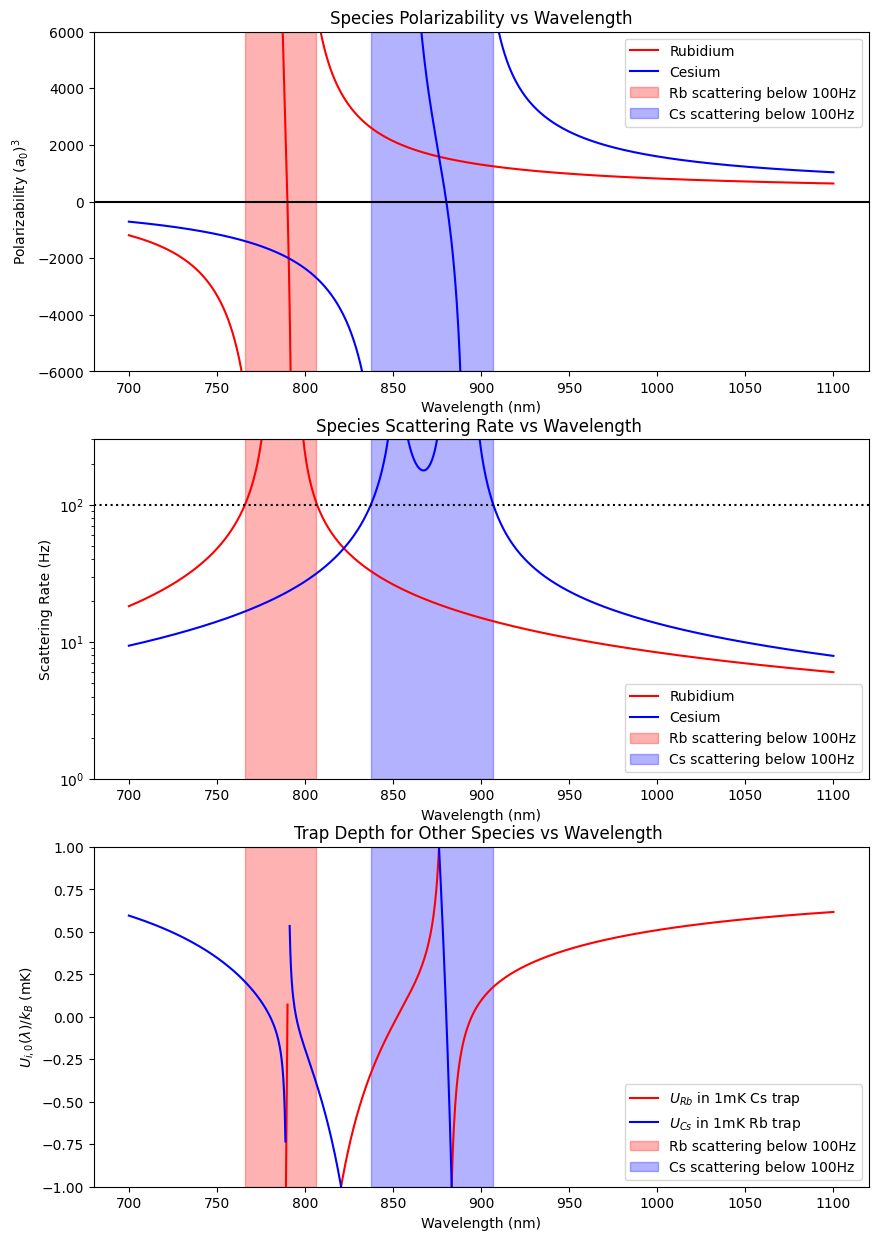

In [4]:
wavelength_range = np.linspace(700,1100,1000)*1e-9
Rb_wvl_pol, Cs_wvl_pol, Rb_tweezer_scat_rate, Cs_tweezer_scat_rate, [Rb_scat_low, Rb_scat_high], [Cs_scat_low, Cs_scat_high], Rb_trap_temp_from_Cs, Cs_trap_temp_from_Rb = calc_pol_scat_U(wavelength_range)

In [5]:
# Widgets for parameters
def fig1parameters(wavelength, wavelength_range, Rb_wvl_pol, Cs_wvl_pol, Rb_tweezer_scat_rate, Cs_tweezer_scat_rate, Rb_trap_temp_from_Cs, Cs_trap_temp_from_Rb):
    wvl_i = np.argmin(np.abs(wavelength_range - wavelength))
    alpha_Rb = Rb_wvl_pol[wvl_i]
    alpha_Cs = Cs_wvl_pol[wvl_i]
    scat_Rb = Rb_tweezer_scat_rate[wvl_i]
    scat_Cs = Cs_tweezer_scat_rate[wvl_i]
    temp_Rb_from_Cs = Rb_trap_temp_from_Cs[wvl_i]
    temp_Cs_from_Rb = Cs_trap_temp_from_Rb[wvl_i]

    print(f"Polarizability of Rubidium {alpha_Rb:.3f} a0^3")
    print(f"Polarizability of Cesium {alpha_Cs:.3f} a0^3")
    print(f"Ratio of polarizability Rb/Cs = {alpha_Rb/alpha_Cs:.3f} and Cs/Rb = {alpha_Cs/alpha_Rb:.3f}")
    print(f"Scattering Rate of Rb Tweezers (D1+D2) = {scat_Rb:.3f} Hz")
    print(f"Scattering Rate of Cs Tweezers (D1+D2) = {scat_Cs:.3f} Hz")
    print(f"Trap Temperature Felt by Rb from 1mK Cs Trap at this wavelength = {temp_Rb_from_Cs:.3f} mK")
    print(f"Trap Temperature Felt by Cs from 1mK Rb Trap at this wavelength = {temp_Cs_from_Rb:.3f} mK")
    print("")


print("Cornish Rb Tweezer Wavelength: 814 nm")
fig1parameters(814e-9, wavelength_range, Rb_wvl_pol, Cs_wvl_pol, Rb_tweezer_scat_rate, Cs_tweezer_scat_rate, Rb_trap_temp_from_Cs, Cs_trap_temp_from_Rb)

print("Cornish Cs Tweezer Wavelength: 938 nm")
fig1parameters(938e-9, wavelength_range, Rb_wvl_pol, Cs_wvl_pol, Rb_tweezer_scat_rate, Cs_tweezer_scat_rate, Rb_trap_temp_from_Cs, Cs_trap_temp_from_Rb)

print("Hannes 1.0 Rb Tweezer Wavelength: 811 nm")
fig1parameters(811e-9, wavelength_range, Rb_wvl_pol, Cs_wvl_pol, Rb_tweezer_scat_rate, Cs_tweezer_scat_rate, Rb_trap_temp_from_Cs, Cs_trap_temp_from_Rb)

print("Hannes 1.0 Rb Tweezer Wavelength: 910 nm")
fig1parameters(910e-9, wavelength_range, Rb_wvl_pol, Cs_wvl_pol, Rb_tweezer_scat_rate, Cs_tweezer_scat_rate, Rb_trap_temp_from_Cs, Cs_trap_temp_from_Rb)

print("Our Rb Tweezer Wavelength: 809 nm")
fig1parameters(809e-9, wavelength_range, Rb_wvl_pol, Cs_wvl_pol, Rb_tweezer_scat_rate, Cs_tweezer_scat_rate, Rb_trap_temp_from_Cs, Cs_trap_temp_from_Rb)

print("Our Cs Tweezer Wavelength: 1064 nm")
fig1parameters(1064e-9, wavelength_range, Rb_wvl_pol, Cs_wvl_pol, Rb_tweezer_scat_rate, Cs_tweezer_scat_rate, Rb_trap_temp_from_Cs, Cs_trap_temp_from_Rb)

Cornish Rb Tweezer Wavelength: 814 nm
Polarizability of Rubidium 4755.975 a0^3
Polarizability of Cesium -3223.260 a0^3
Ratio of polarizability Rb/Cs = -1.476 and Cs/Rb = -0.678
Scattering Rate of Rb Tweezers (D1+D2) = 65.137 Hz
Scattering Rate of Cs Tweezers (D1+D2) = 37.951 Hz
Trap Temperature Felt by Rb from 1mK Cs Trap at this wavelength = -1.476 mK
Trap Temperature Felt by Cs from 1mK Rb Trap at this wavelength = -0.678 mK

Cornish Cs Tweezer Wavelength: 938 nm
Polarizability of Rubidium 1043.050 a0^3
Polarizability of Cesium 2925.001 a0^3
Ratio of polarizability Rb/Cs = 0.357 and Cs/Rb = 2.804
Scattering Rate of Rb Tweezers (D1+D2) = 11.449 Hz
Scattering Rate of Cs Tweezers (D1+D2) = 28.993 Hz
Trap Temperature Felt by Rb from 1mK Cs Trap at this wavelength = 0.357 mK
Trap Temperature Felt by Cs from 1mK Rb Trap at this wavelength = 2.804 mK

Hannes 1.0 Rb Tweezer Wavelength: 811 nm
Polarizability of Rubidium 5435.505 a0^3
Polarizability of Cesium -2979.915 a0^3
Ratio of polarizabi